# 🏞️ Watersheds from GeoParquet — Marys River / Willamette Confluence, Oregon

## What this notebook does

Just another example workflow playing with Geoparquet and GeoLibre. Everything runs in memory or via HTTP range requests — **no files are downloaded or saved**. The full stack is:

```
Overture Maps (GeoParquet, public S3, hive-partitioned by bbox)
    ↓  HTTP range requests — bbox pushdown skips row groups that don't overlap
DuckDB (Python) — spatial + httpfs extensions, ST_AsWKB(geometry) in the query
    ↓  WKB bytes → GeoDataFrame (shapely.wkb.loads)
Microsoft Planetary Computer STAC API
    ↓  finds the 3DEP elevation Cloud-Optimized GeoTIFF covering the bbox
rioxarray — rio.clip_box() triggers windowed reads only, never the full raster
    ↓  GeoJSON + a signed COG url
GeoLibre widget — full GIS app in the notebook cell
```

### Hydrography summary (Marys River watershed area, ~250 km² window)
| | Streams / rivers / canals | Lakes / ponds / reservoirs |
|---|---|---|
| **Features returned** | 592 | 59 |
| **Total length / area** | 435.9 km (350.8 stream + 78.9 river + 6.2 canal) | 42.8 ha (12.8 lake + 26.7 pond + 3.3 reservoir) |
| **Source** | Overture Maps `base/water`, release `2026-07-22.0` | same |
| **Elevation range in window** | 54 – 659 m (USGS 3DEP seamless DEM) | |

Swap in any bounding box — DuckDB only touches the Parquet row groups that overlap it, and the DEM read only pulls the pixels under it.

## Install

In [1]:
# [Python]
%pip install --quiet --upgrade duckdb geopandas pystac-client planetary-computer rioxarray geolibre

Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pygis 0.10.2 requires anymap, which is not installed.


## Query Overture Maps water theme with DuckDB

The `base/water` theme is published as hive-partitioned GeoParquet on S3 — tens of gigabytes
worldwide. Every row carries a `bbox` struct alongside its geometry, and DuckDB uses it to prune
Parquet row groups *before* fetching geometry bytes, so a small bounding-box query only reads the
handful of row groups that actually overlap it. The bucket is public — no credentials needed.

In [ ]:
# [Python]
import duckdb, json
import pandas as pd
import geopandas as gpd
from shapely import wkb

xmin, ymin, xmax, ymax = -123.45, 44.45, -123.15, 44.65
RELEASE = "2026-07-22.0"
WATER_PATH = f"s3://overturemaps-us-west-2/release/{RELEASE}/theme=base/type=water/*"

con = duckdb.connect()
con.execute("""
    INSTALL spatial; LOAD spatial;
    INSTALL httpfs;  LOAD httpfs;
    SET s3_region = 'us-west-2';
""")

# ── Step 1: DESCRIBE — see what columns exist ────────────────────────────────
schema = con.execute(f"DESCRIBE SELECT * FROM read_parquet('{WATER_PATH}') LIMIT 0").df()
print("Available columns:")
print(schema[["column_name", "column_type"]].to_string(index=False))
print()

# ── Step 2: query — bbox-pushdown filter, WKB bytes for GeoPandas ────────────
def overture_water(subtypes):
    subtype_list = ", ".join(f"'{s}'" for s in subtypes)
    sql = f"""
        SELECT id, names.primary AS name, subtype, class,
               ST_AsWKB(geometry) AS geom_wkb
        FROM   read_parquet('{WATER_PATH}', hive_partitioning = 1)
        WHERE  bbox.xmin BETWEEN {xmin} AND {xmax}
          AND  bbox.ymin BETWEEN {ymin} AND {ymax}
          AND  subtype IN ({subtype_list})
    """
    raw = con.execute(sql).df()
    # DuckDB returns WKB as bytearray; shapely.wkb.loads wants bytes.
    geom = raw["geom_wkb"].apply(bytes).apply(wkb.loads)
    return gpd.GeoDataFrame(raw.drop(columns=["geom_wkb"]), geometry=geom, crs="EPSG:4326")

rivers = overture_water(["river", "stream", "canal"])
waterbodies = overture_water(["lake", "pond", "reservoir"])

print(f"Rows from DuckDB : {len(rivers)} streams/rivers/canals, {len(waterbodies)} waterbodies")
rivers.head()

Available columns:
    column_name                                                                                                                                                                                                               column_type
             id                                                                                                                                                                                                                   VARCHAR
          names STRUCT("primary" VARCHAR, common MAP(VARCHAR, VARCHAR), rules STRUCT(variant VARCHAR, "language" VARCHAR, perspectives STRUCT("mode" VARCHAR, countries VARCHAR[]), "value" VARCHAR, "between" DOUBLE[], side VARCHAR)[])
        subtype                                                                                                                                                                                                                   VARCHAR
          class                              

,id,name,subtype,class,geometry
0,54c6e5bb-2137-3681-b633-857f0840c4ff,None,stream,stream,"LINESTRING (-123.39729 44.45251, -123.39707 44..."
1,27069764-26d0-3de9-bfd9-538a9eeb0b6f,None,stream,stream,"LINESTRING (-123.39687 44.45259, -123.39688 44..."
2,c42ea4a5-73e3-3536-b354-6a448f2754df,None,stream,stream,"LINESTRING (-123.40596 44.45006, -123.40589 44..."
3,e6342968-c137-3479-8701-7069197596ba,Powell Creek,stream,stream,"LINESTRING (-123.4258 44.47226, -123.42539 44...."
4,ff5786ad-2cdd-3e34-ab1b-d225cb3ac76b,Mercer Creek,stream,stream,"LINESTRING (-123.42127 44.47749, -123.42091 44..."


## Push the stats into SQL

DuckDB's spatial functions run before any geometry reaches Python, so length and area come out of
the same bbox-limited scan. `always_xy := true` matters here — without it `ST_Transform` follows
the EPSG:4326 *authority* axis order (lat, lon) instead of (lon, lat), and silently returns
`Infinity` instead of raising an error.

In [2]:
# [Python]
length_sql = f"""
    SELECT subtype, count(*) AS n_features,
           round(sum(ST_Length(ST_Transform(geometry, 'EPSG:4326', 'EPSG:5070',
                                             always_xy := true))) / 1000, 1) AS length_km
    FROM   read_parquet('{WATER_PATH}', hive_partitioning = 1)
    WHERE  bbox.xmin BETWEEN {xmin} AND {xmax} AND bbox.ymin BETWEEN {ymin} AND {ymax}
      AND  subtype IN ('river', 'stream', 'canal')
    GROUP BY subtype ORDER BY length_km DESC
"""
area_sql = f"""
    SELECT subtype, count(*) AS n_features,
           round(sum(ST_Area(ST_Transform(geometry, 'EPSG:4326', 'EPSG:5070',
                                           always_xy := true))) / 10000, 1) AS area_ha
    FROM   read_parquet('{WATER_PATH}', hive_partitioning = 1)
    WHERE  bbox.xmin BETWEEN {xmin} AND {xmax} AND bbox.ymin BETWEEN {ymin} AND {ymax}
      AND  subtype IN ('lake', 'pond', 'reservoir')
    GROUP BY subtype ORDER BY area_ha DESC
"""
print("Stream network length by subtype:")
print(con.execute(length_sql).fetchdf().to_string(index=False))
print("\nWaterbody area by subtype:")
print(con.execute(area_sql).fetchdf().to_string(index=False))

Stream network length by subtype:
subtype  n_features  length_km
 stream         561      350.8
  river          17       78.9
  canal          14        6.2

Waterbody area by subtype:
  subtype  n_features  area_ha
     pond          49     26.7
     lake           6     12.8
reservoir           4      3.3


## Elevation via STAC — a Cloud-Optimized GeoTIFF, no download

[Microsoft Planetary Computer](https://planetarycomputer.microsoft.com/) catalogs the USGS
[3DEP seamless](https://planetarycomputer.microsoft.com/dataset/3dep-seamless) 1/3 arc-second DEM
through STAC. `pystac-client` finds the item that covers our bbox, `planetary_computer.sign_inplace`
appends the SAS token the asset needs, and `rio.clip_box()` only triggers reads for the raster
windows that intersect the box — the ~470 MB backing tile is never pulled in full.

In [3]:
# [Python]
import pystac_client
import planetary_computer
import rioxarray

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

items = list(catalog.search(collections=["3dep-seamless"], bbox=[xmin, ymin, xmax, ymax]).items())
print(f"{len(items)} matching STAC item(s): {[i.id for i in items]}")

dem_href = items[0].assets["data"].href
dem = rioxarray.open_rasterio(dem_href, masked=True)
dem_clip = dem.rio.clip_box(minx=xmin, miny=ymin, maxx=xmax, maxy=ymax, crs="EPSG:4326").squeeze()

elev_min, elev_max = float(dem_clip.min()), float(dem_clip.max())
print(f"Clipped window: {dem_clip.shape}, elevation range: {elev_min:.0f}-{elev_max:.0f} m")

2 matching STAC item(s): ['n45w124-13', 'n45w124-1']
Clipped window: (2161, 3241), elevation range: 54-659 m


## Assemble GeoJSON in memory

GeoLibre's `add_geojson()` takes a raw GeoJSON string, a dict, or a GeoDataFrame directly — going
through an explicit `FeatureCollection` here just makes the properties we're keeping obvious.

In [4]:
# [Python]
def to_feature_collection(gdf, prop_cols):
    features = [
        {
            "type": "Feature",
            "properties": {c: (None if pd.isna(row[c]) else row[c]) for c in prop_cols},
            "geometry": row.geometry.__geo_interface__,
        }
        for _, row in gdf.iterrows()
    ]
    return {"type": "FeatureCollection", "features": features}

rivers_fc = to_feature_collection(rivers, ["id", "name", "subtype", "class"])
waterbodies_fc = to_feature_collection(waterbodies, ["id", "name", "subtype", "class"])

print(f"rivers_fc ready: {len(rivers_fc['features'])} feature(s)")
print(f"waterbodies_fc ready: {len(waterbodies_fc['features'])} feature(s)")

rivers_fc ready: 592 feature(s)
waterbodies_fc ready: 59 feature(s)


## Visualize in GeoLibre

Three layers in one widget: the DEM as a colored terrain COG (rendered client-side straight from
the signed Planetary Computer url — still no download), streams, and waterbodies.

In [5]:
# [Python]
from geolibre import Map

m = Map(center=((xmin + xmax) / 2, (ymin + ymax) / 2), zoom=11)
m.add_basemap("positron")

m.add_cog(dem_href, name="3DEP elevation", colormap="terrain",
          rescale=[[elev_min, elev_max]])
m.add_geojson(waterbodies_fc, name="Lakes & ponds", color="#1c5fa8", fillOpacity=0.6)
m.add_geojson(rivers_fc, name="Streams & rivers", color="#4fc3f7", weight=1.5)

m

## Static hillshade view (matplotlib)

A plain PNG version of the same three layers, for anywhere the interactive widget doesn't travel
(RSS readers, printed copies, this being a blog post that also needs to work as a static page).

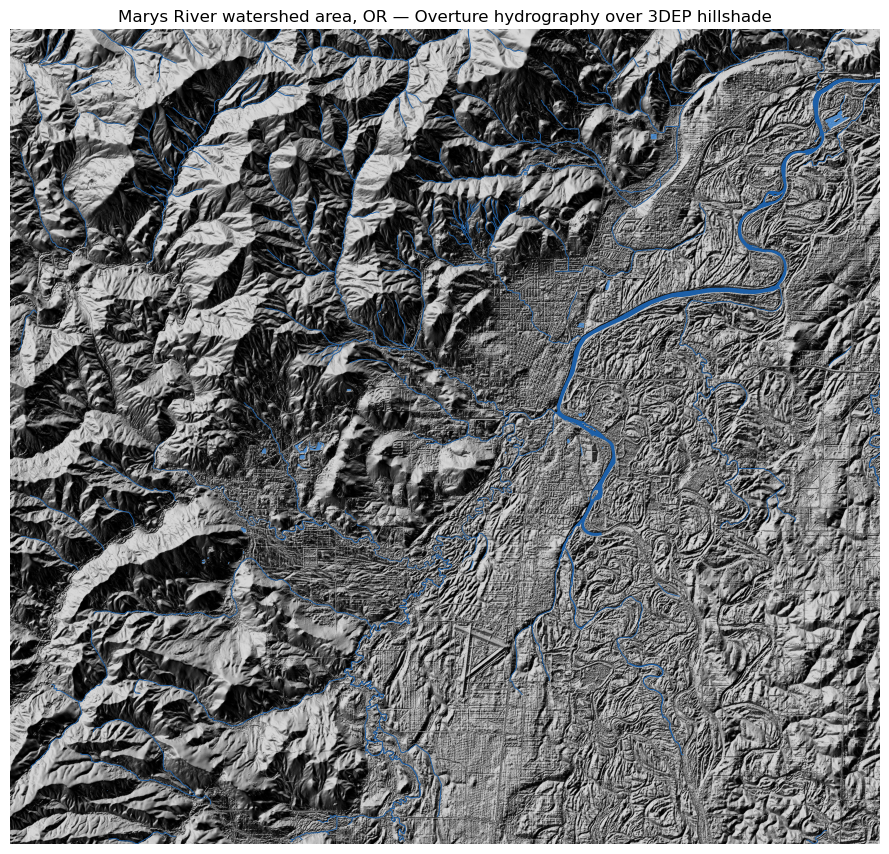

In [6]:
# [Python]
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource

fig, ax = plt.subplots(figsize=(9, 9))
ls = LightSource(azdeg=315, altdeg=45)
dx = abs(float(dem_clip.x[1] - dem_clip.x[0]))
dy = abs(float(dem_clip.y[1] - dem_clip.y[0]))
hillshade = ls.hillshade(dem_clip.values, vert_exag=1.5, dx=dx, dy=dy)

ax.imshow(hillshade, cmap="gray", extent=[xmin, xmax, ymin, ymax], origin="upper")
waterbodies.plot(ax=ax, color="#4a90d9", edgecolor="none", alpha=0.85, zorder=2)
rivers.plot(ax=ax, color="#1c5fa8", linewidth=0.6, zorder=3)
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_axis_off()
ax.set_title("Marys River watershed area, OR — Overture hydrography over 3DEP hillshade")
fig.tight_layout()
plt.show()

> **GeoLibre quick tips**
> - Click a polygon or line → **Identify** shows `name`, `subtype`, `class`
> - Bottom-left table icon → **Attribute Table** with filter, sort, export
> - **SQL Workspace** (`Ctrl+Shift+D`) → query the live layer with DuckDB Spatial SQL
> - **Project → Share** → upload to `share.geolibre.app` for a static shareable link

---

## 🔧 Try it yourself

1. Change `xmin, ymin, xmax, ymax` to any bounding box and re-run — DuckDB only touches the Overture
   row groups that overlap the new box, and `rio.clip_box` only reads the DEM pixels under it.
2. Swap the Overture `base/water` theme for `base/land_cover` or `base/infrastructure` (same S3
   prefix pattern, different `type=` partition) to layer in more context.
3. In the GeoLibre SQL Workspace, run something like:
   ```sql
   SELECT name, ST_Length(geometry) AS length_deg
   FROM "Streams & rivers"
   ORDER BY length_deg DESC
   ```
4. Swap the `3dep-seamless` collection for `naip` on the same STAC catalog to drop in recent aerial
   imagery instead of a DEM — `add_cog` doesn't care which raster it's pointed at.

---

## R equivalent

```r
# install.packages(c("duckdbfs", "sf"))
library(duckdbfs)
library(sf)

con <- cache_connection()
duckdb_secrets(con)   # public bucket, no credentials needed

water <- open_dataset(
  "s3://overturemaps-us-west-2/release/2026-07-22.0/theme=base/type=water/*",
  con = con
) |>
  filter(bbox$xmin > -123.45, bbox$xmax < -123.15,
         bbox$ymin > 44.45,  bbox$ymax < 44.65,
         subtype %in% c("river", "stream", "canal")) |>
  to_sf()

plot(st_geometry(water))
```